## Waveplate
This notebook demonstrates how to propagate dual-polarisation signals through a waveplate model with the tremor-waveplate-toolbox.
We start by generating a signal to transmit (see demo_transmission.ipynb).

In [13]:
from configparser import ConfigParser
from tremor_waveplate_toolbox import Transmitter

parameters = ConfigParser(inline_comment_prefixes = '#')
parameters.read('../config/parameters.ini')

Tx = Transmitter(parameters)
_, signal = Tx.transmit_random((
    parameters.getint('SIGNAL', 'batch_size'),
    int(parameters.getfloat('SIGNAL', 'symbol_count'))
))

Now, let's create a new Waveplate model and propagate the signal through it:

In [ ]:
from tremor_waveplate_toolbox import Waveplate

# Define parameters in code..
parameters['FIBRE'] = {
    'section_length': '0.1',   # Correlation length in km
    'section_count': '1000',   # Number of fibre sections, each of which has length Lc
    'PMD_parameter': '0.1',    # Polarisation mode dispersion parameter in ps / (km ^ 0.5)
    'realisation_count': '10', # Number of fibre realisations to simulate simultaneously
    'photoelasticity': '0.1'   # Photoelasticity, which relates material strain to optical strain
}

# ..or load them from a file
parameters.read('../config/parameters.ini')

# Create the channel with the defined parameters
channel = Waveplate(parameters)

# Propagate the signal through the channel
propagated_signal = channel(signal, verbose = True)

We can plot the transmitted and received signals to compare

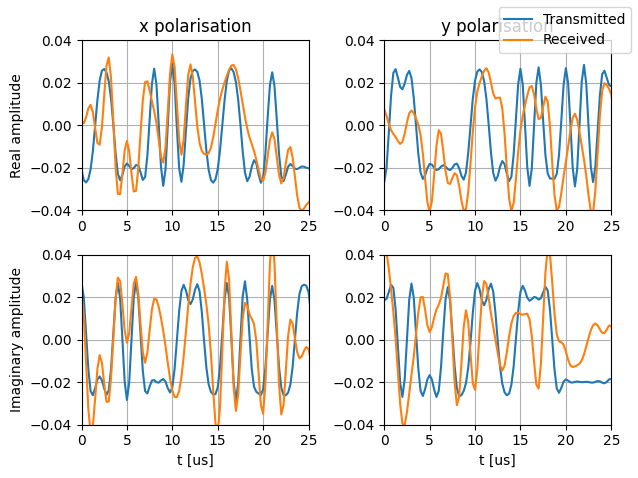

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2)

axes[0, 0].set_title("x polarisation")
axes[0, 0].set_ylabel("Real amplitude")
axes[0, 0].set_ylim([-0.04, 0.04])
axes[0, 0].set_xlim([0, 25])
axes[0, 0].grid()
axes[0, 0].plot(signal.time * 1e6, signal.samples_time[0, 0, :, 0].real)
axes[0, 0].plot(propagated_signal.time * 1e6, propagated_signal.samples_time[0, 0, :, 0].real)

axes[1, 0].set_xlabel("t [us]")
axes[1, 0].set_ylabel("Imaginary amplitude")
axes[1, 0].set_ylim([-0.04, 0.04])
axes[1, 0].set_xlim([0, 25])
axes[1, 0].grid()
axes[1, 0].plot(signal.time * 1e6, signal.samples_time[0, 0, :, 0].imag)
axes[1, 0].plot(propagated_signal.time * 1e6, propagated_signal.samples_time[0, 0, :, 0].imag)

axes[0, 1].set_title("y polarisation")
axes[0, 1].set_ylim([-0.04, 0.04])
axes[0, 1].set_xlim([0, 25])
axes[0, 1].grid()
axes[0, 1].plot(signal.time * 1e6, signal.samples_time[0, 0, :, 1].real)
axes[0, 1].plot(propagated_signal.time * 1e6, propagated_signal.samples_time[0, 0, :, 1].real)

axes[1, 1].set_xlabel("t [us]")
axes[1, 1].set_ylim([-0.04, 0.04])
axes[1, 1].set_xlim([0, 25])
axes[1, 1].grid()
axes[1, 1].plot(signal.time * 1e6, signal.samples_time[0, 0, :, 1].imag)
axes[1, 1].plot(propagated_signal.time * 1e6, propagated_signal.samples_time[0, 0, :, 1].imag)

fig.legend(["Transmitted", "Received"])
fig.tight_layout()

plt.show()